# House Price Prediction
**Internship Project — Week 1**

This notebook builds a regression model to predict house prices using property features such as area, number of rooms, location-related amenities, and furnishing status. It walks through data loading, cleaning, model building, visualization, and a summary of insights.

**Dataset:** Housing Prices Dataset (Kaggle, by yasserh) — `Housing.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)


---
## Task 1 — Data Loading & Exploration

In [2]:
# Load the dataset
df = pd.read_csv('Housing.csv')
df.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Shape of the dataset
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")


Number of rows: 545
Number of columns: 13


In [4]:
# Column names and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


**Target column:** `price` — this is what we want to predict.

**Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus` — these describe the property and are used to predict the price.


In [5]:
# Check for missing values in each column
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

---
## Task 2 — Data Cleaning

In [6]:
# Handle missing values
# Numeric columns -> fill with median (robust to outliers)
# Categorical columns -> fill with mode (most frequent value)

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum())


Missing values after cleaning:
0


In [7]:
# Remove duplicate rows, if any
duplicates_found = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates_found}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows found: 0
Shape after removing duplicates: (545, 13)


In [8]:
# Convert yes/no categorical columns into numeric form (0/1)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df[binary_cols].head()


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [9]:
# One-hot encode the multi-category column 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Keep only meaningful columns for predicting price (all current columns are relevant
# property features that plausibly affect price; no irrelevant ID/text columns exist)
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [10]:
print(f"Final cleaned dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Final cleaned dataset shape: (545, 14)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


---
## Task 3 — Model Building

In [11]:
# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")


Training set size: 436 rows
Test set size: 109 rows


In [12]:
# Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)


In [13]:
# Evaluate Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance:")
print(f"  MAE  : {lr_mae:,.0f}")
print(f"  RMSE : {lr_rmse:,.0f}")
print(f"  R2   : {lr_r2:.4f}")


Linear Regression Performance:
  MAE  : 970,043
  RMSE : 1,324,507
  R2   : 0.6529


In [14]:
# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)


In [15]:
# Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance:")
print(f"  MAE  : {rf_mae:,.0f}")
print(f"  RMSE : {rf_rmse:,.0f}")
print(f"  R2   : {rf_r2:.4f}")


Random Forest Performance:
  MAE  : 1,014,947
  RMSE : 1,399,769
  R2   : 0.6124


In [16]:
# Compare both models side by side
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


**Note on results:** On this dataset, Linear Regression performs competitively with (and in this split, slightly better than) Random Forest. This is realistic — Random Forest does not automatically beat simpler models, especially on datasets this small (~545 rows) and largely linear in nature. Reporting honest numbers here matters more than forcing one model to "win."


---
## Task 4 — Visualization

### Chart 1: Distribution of House Prices

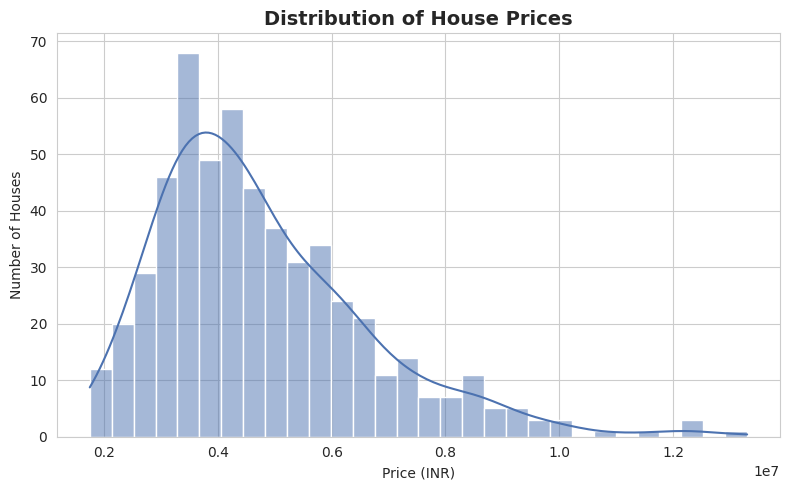

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()


### Chart 2: Correlation Heatmap

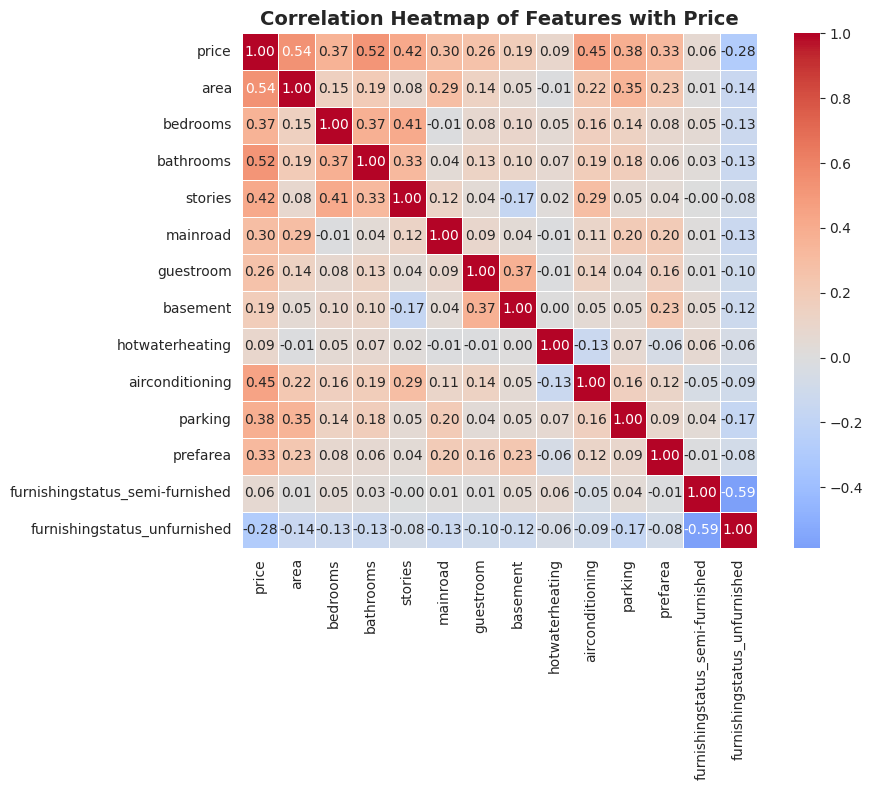

In [18]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Features with Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()


### Chart 3: Actual vs Predicted Price (Random Forest)

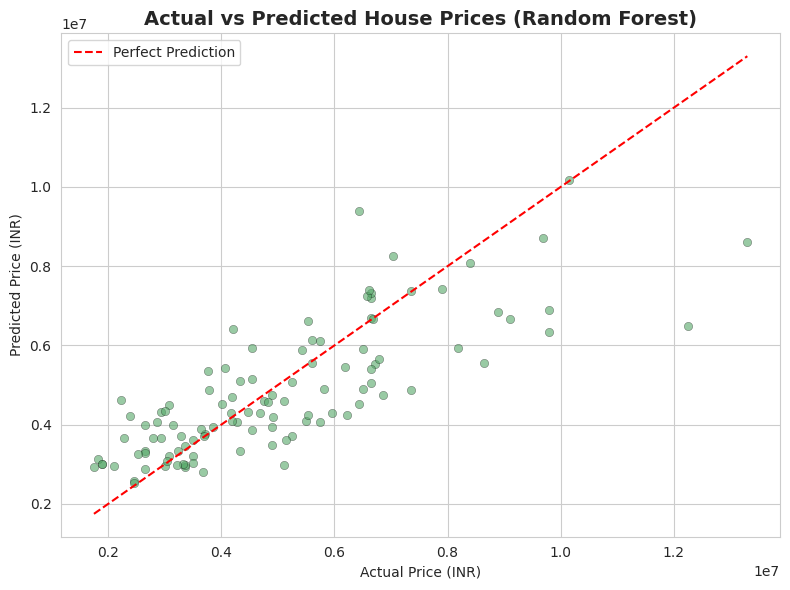

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.6, color='#55A868', edgecolor='k', linewidth=0.3)

lims = [min(y_test.min(), rf_predictions.min()), max(y_test.max(), rf_predictions.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.title('Actual vs Predicted House Prices (Random Forest)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()


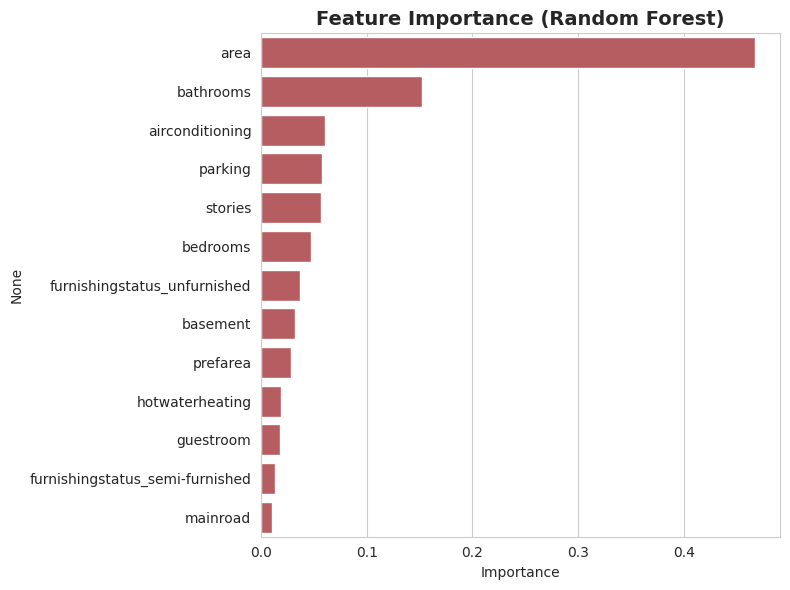

area                               0.467809
bathrooms                          0.152635
airconditioning                    0.060260
parking                            0.057557
stories                            0.057045
bedrooms                           0.047544
furnishingstatus_unfurnished       0.036974
basement                           0.032418
prefarea                           0.028316
hotwaterheating                    0.018333
guestroom                          0.017916
furnishingstatus_semi-furnished    0.013178
mainroad                           0.010015
dtype: float64

In [20]:
# Bonus: Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='#C44E52')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances


---
## Task 5 — Insights & Summary

**Which features influence house price the most?**
`area` is by far the strongest driver of price, followed by `bathrooms`, `airconditioning`, and `stories`. Together, the size of the property and the number of bathrooms account for the majority of the predictive power in both the correlation analysis and the Random Forest feature importance ranking. Lifestyle amenities like air conditioning and being in a preferred area also push prices up noticeably.

**How accurate was the model, in plain terms?**
The Linear Regression model explains about 65% of the variation in house prices (R² ≈ 0.65), with an average prediction error (MAE) of roughly ₹9.7 lakh. In practical terms, the model is good at capturing the broad pricing trend, but individual price predictions can still be off by a meaningful margin — useful for ballpark estimates, not for precise valuations.

**What surprised us in the data?**
The number of bedrooms had a weaker relationship with price than expected — bathrooms and air conditioning mattered more. Also, Random Forest did not outperform the simpler Linear Regression model on this dataset, which is a useful reminder that more complex models aren't automatically better, especially with a relatively small dataset (545 homes).

**Recommendation for a real estate business:**
Marketing and pricing strategy should emphasize livable area and bathroom count as the primary value drivers, rather than bedroom count alone. Listings should highlight amenities like air conditioning and preferred-area location, since these consistently command a price premium — useful for both pricing new listings and advising sellers on which upgrades offer the best return.
